<div style="text-align: center;">

<!-- color:#e06666 -->
<h3 style="font-weight: normal; margin-bottom: 10px;">
EN3160 Assignment 01
</h3>

<h3 style="font-weight: normal; line-height: 1.5; margin-top: 0;">
Intensity Transformations and Neighborhood Filtering
</h3>

<!-- <br><br> -->

<h4 style="font-family: 'Times New Roman', serif; font-weight: normal; margin-top: 0; line-height: 1.4;">
230138K  - K.T.G.T.N.Dhananjaya 
</h4>

<br>
<!-- <h4 style="font-family: 'Times New Roman', serif; font-weight: normal;">
September 4, 2026
</h4> -->

</div>

<a href="https://github.com/TharushaNimesh22/intensity-transformations-and-neighborhood-filtering">GitHub Link: https://github.com/TharushaNimesh22/intensity-transformations-and-neighborhood-filtering </a>

##### 1. Intensity Transformation

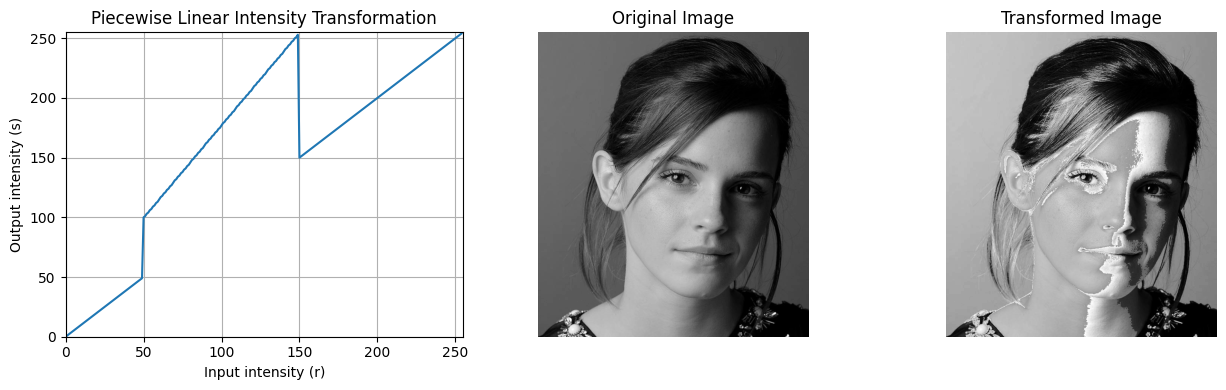

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    transformed = np.zeros_like(im, dtype=np.uint8)
    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]
        # Calculate the slope (m) and intercept (b) of the line segment
        if x1 - x0 != 0:
            m = (y1 - y0) / (x1 - x0)
            b = y0 - m * x0
        else:
            m, b = 0, y0
        # Apply the linear transformation for the current segment
        mask = (im >= x0) & (im < x1)
        transformed[mask] = np.clip(m * im[mask] + b, 0, 255)
    return transformed.astype(np.uint8)

# Read image using OpenCV
im = cv.imread("images/emma.jpeg", cv.IMREAD_GRAYSCALE)
breakpoints = np.array([[0, 0], [50, 50],[50, 100], [150, 255],[150, 150], 
                        [255, 255],])
transformed = intensity_transform(im, breakpoints)
# Plot the transformation function
r = np.arange(255)
s = intensity_transform(r, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(r, s)    # Transformation function
axes[0].set(xlabel="Input intensity (r)", ylabel="Output intensity (s)", 
            title="Piecewise Linear Intensity Transformation", xlim=(0, 255), ylim=(0, 255))
axes[0].grid()
axes[1].imshow(im, cmap="gray")    # Original image
axes[1].set_title("Original Image")
axes[1].axis("off")
axes[2].imshow(transformed, cmap="gray")  # Transformed image
axes[2].set_title("Transformed Image")
axes[2].axis("off")
plt.tight_layout()
plt.show()

##### 2. Intensity transformers for white matter and gray matter

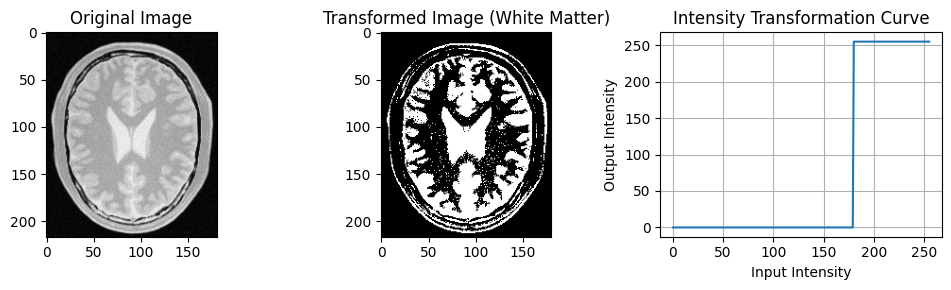

In [ ]:
f = cv.imread("images/brain.png", cv. IMREAD_GRAYSCALE)
#part a). White matter enhancement
t1= np.linspace(0, 0, 180, endpoint=False).astype("uint8")
t2= np.linspace(255, 255, 76).astype("uint8")
tr1= np.concatenate((t1, t2)).reshape(256, 1)

img_wm = cv.LUT(f, tr1)
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original Image")
ax[1].imshow(img_wm, cmap='gray', vmin=0, vmax=255)
ax[1].set_title("Transformed Image (White Matter)")
ax[2].plot(tr1)
ax[2].set_title("Intensity Transformation Curve")
ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity")
ax[2].grid(True)

plt.tight_layout()
plt.show()

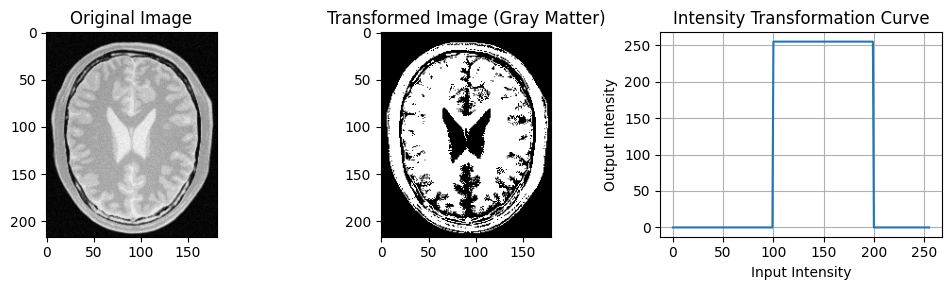

In [5]:
# Gray matter enhancement
gm_low = np.linspace(0, 0, 100, endpoint=False).astype("uint8")
gm_boost = np.linspace(255, 255, 100, endpoint=False).astype("uint8")
gm_high = np.linspace(0, 0, 56).astype("uint8")
tr_gm = np.concatenate((gm_low, gm_boost, gm_high)).reshape(256, 1)

img_gm = cv.LUT(f, tr_gm)
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255); ax[0].set_title("Original Image")

ax[1].imshow(img_gm, cmap='gray', vmin=0, vmax=255);
ax[1].set_title("Transformed Image (Gray Matter)");ax[2].plot(tr_gm)
ax[2].set_title("Intensity Transformation Curve"); ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity");ax[2].grid(True)
plt.tight_layout()
plt.show()



##### 3. Gamma correction

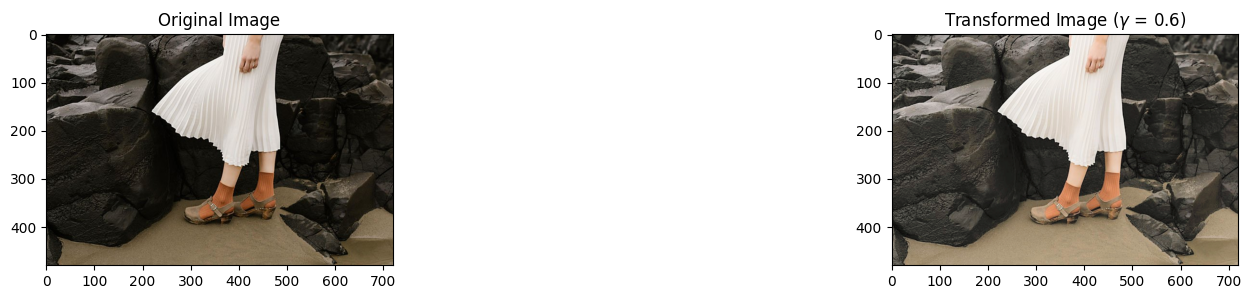

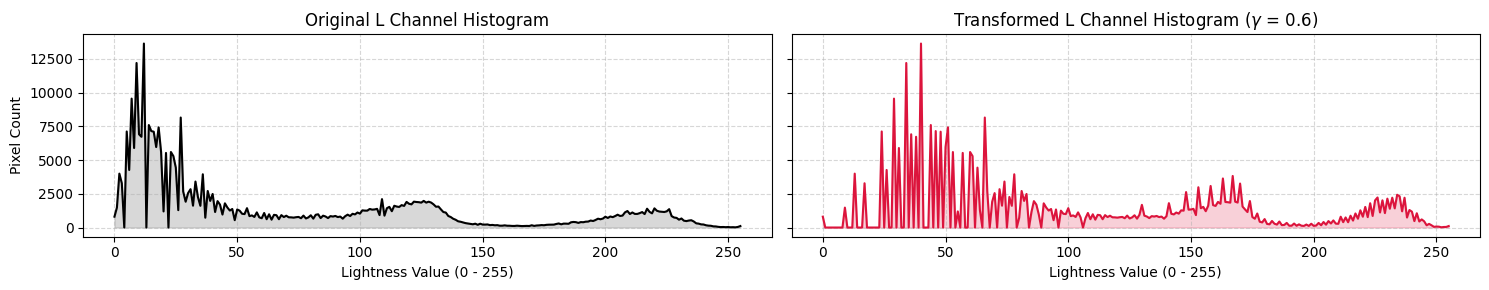

y Value: 0.6


In [10]:
fig = cv.imread("images/girl.jpeg")

rgb_original = cv.cvtColor(fig, cv.COLOR_BGR2RGB)

img_lab = cv.cvtColor(fig, cv.COLOR_BGR2LAB)
L, a, b = cv.split(img_lab) #splitting to L*a*b planes

gamma= 0.6
tr = np.array([(((i/255) ** gamma)*255) for i in range(256)], dtype=np.uint8)
L_new = cv.LUT(L, tr) #Transformation

modified= cv.merge([L_new, a, b])
bgr_result = cv.cvtColor(modified, cv.COLOR_LAB2BGR)
rgb_result = cv.cvtColor(bgr_result, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(20, 3))

ax[0].imshow(rgb_original)
ax[0].set_title("Original Image")
ax[1].imshow(rgb_result)
ax[1].set_title(rf"Transformed Image ($\gamma$ = {gamma})")
# Plotting the histogram
hist_before = cv.calcHist([L], [0], None, [256], [0, 256])
hist_after = cv.calcHist([L_new], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1, 2, figsize=(15, 3), sharey=True)
# Original L Channel Histogram
ax[0].plot(hist_before, color="black", linewidth=1.5)
ax[0].fill_between(range(256), hist_before.ravel(), color="gray", alpha=0.3)
ax[0].set_title("Original L Channel Histogram")
ax[0].set_xlabel("Lightness Value (0 - 255)")
ax[0].set_ylabel("Pixel Count")
ax[0].grid(True, linestyle="--", alpha=0.5)
# Transformed L Channel Histogram
ax[1].plot(hist_after, color="crimson", linewidth=1.5)
ax[1].fill_between(range(256), hist_after.ravel(), color="crimson", alpha=0.2)
ax[1].set_title(rf"Transformed L Channel Histogram ($\gamma$ = {gamma})")
ax[1].set_xlabel("Lightness Value (0 - 255)")
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
print(f"y Value: {gamma}")

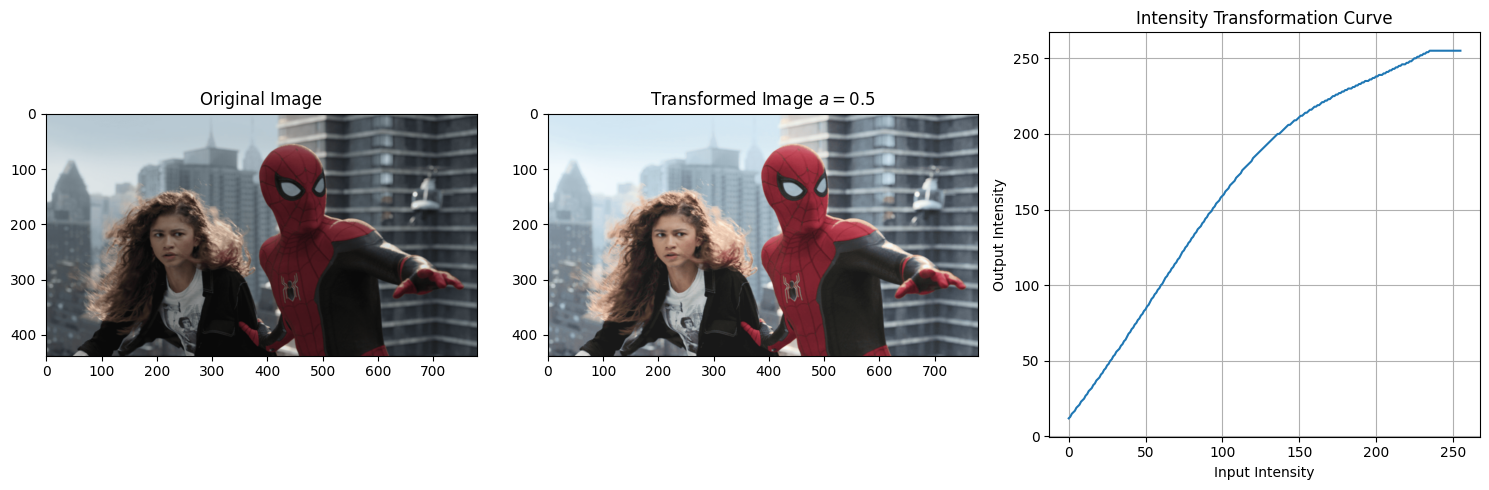

In [13]:
#Question 4
fig= cv.imread("images/peter.png")
rgb_original= cv.cvtColor(fig, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(fig, cv.COLOR_BGR2HSV) # convert to hue, sturation, and va
h, s,v= cv.split(img_hsv)

a=0.5; sigma=70;
def f(x):
    return min(x+a*128*np.exp(-(x-128) ** 2/(2*sigma ** 2)),255)

tr = np.array([np.round(f(i)) for i in range(256)], dtype=np.uint8)
v_new=cv. LUT(v, tr)
modified= cv.merge([h,s,v_new])
bgr_result = cv.cvtColor(modified, cv.COLOR_HSV2BGR)
rgb_result = cv.cvtColor(bgr_result, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(rgb_original); ax[0].set_title("Original Image")
ax[1].imshow(rgb_result);ax[1].set_title(f"Transformed Image $a=${a}")
ax[2].plot(tr);
ax[2].set_title("Intensity Transformation Curve");ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity");ax[2].grid(True)
plt.tight_layout()
plt.show()

##### 5. Histogram Equalizer

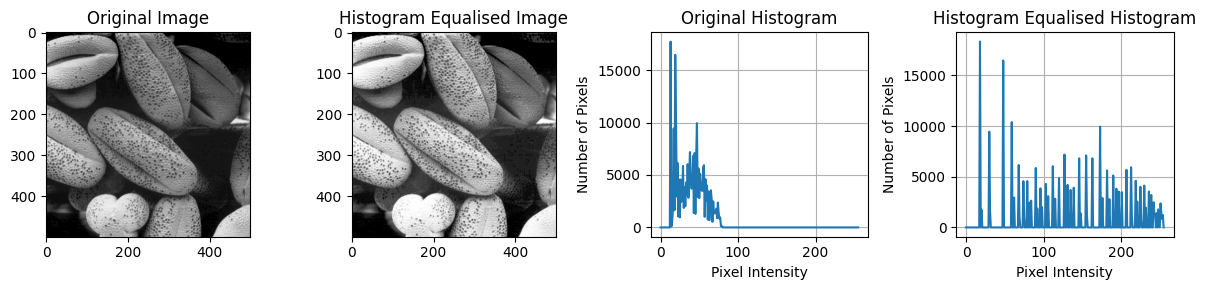

In [14]:
# Question 5
img = cv.imread("images/shells.tif", cv.IMREAD_GRAYSCALE)

def hist_equalisation(img):
    M, N = img.shape
    hist = cv.calcHist([img], [0], None, [256], [0, 256])
    cdf = hist.cumsum()
    tr = np.array([(255 * cdf[i]) / (M * N) for i in range(256)]).astype(np.uint8)
    return tr
tr = hist_equalisation(img)
new_img = cv.LUT(img, tr)
hist_original = cv.calcHist([img], [0], None, [256], [0, 256])
hist_new = cv.calcHist([new_img], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1,4, figsize=(12, 3))
ax[0].imshow(img, cmap='gray'); ax[0].set_title("Original Image")
ax[1].imshow(new_img, cmap='gray');ax[1].set_title("Histogram Equalised Image")
ax[2].plot(hist_original);ax[2].set_title("Original Histogram");
ax[2].set_xlabel("Pixel Intensity");ax[2].set_ylabel("Number of Pixels")
ax[3].plot(hist_new);ax[3].set_title("Histogram Equalised Histogram");
ax[3].set_xlabel("Pixel Intensity");ax[3].set_ylabel("Number of Pixels")
ax[2].grid(True); ax[3].grid(True)
plt.tight_layout()
plt.show()

##### 6. Histogram Equalized Foreground

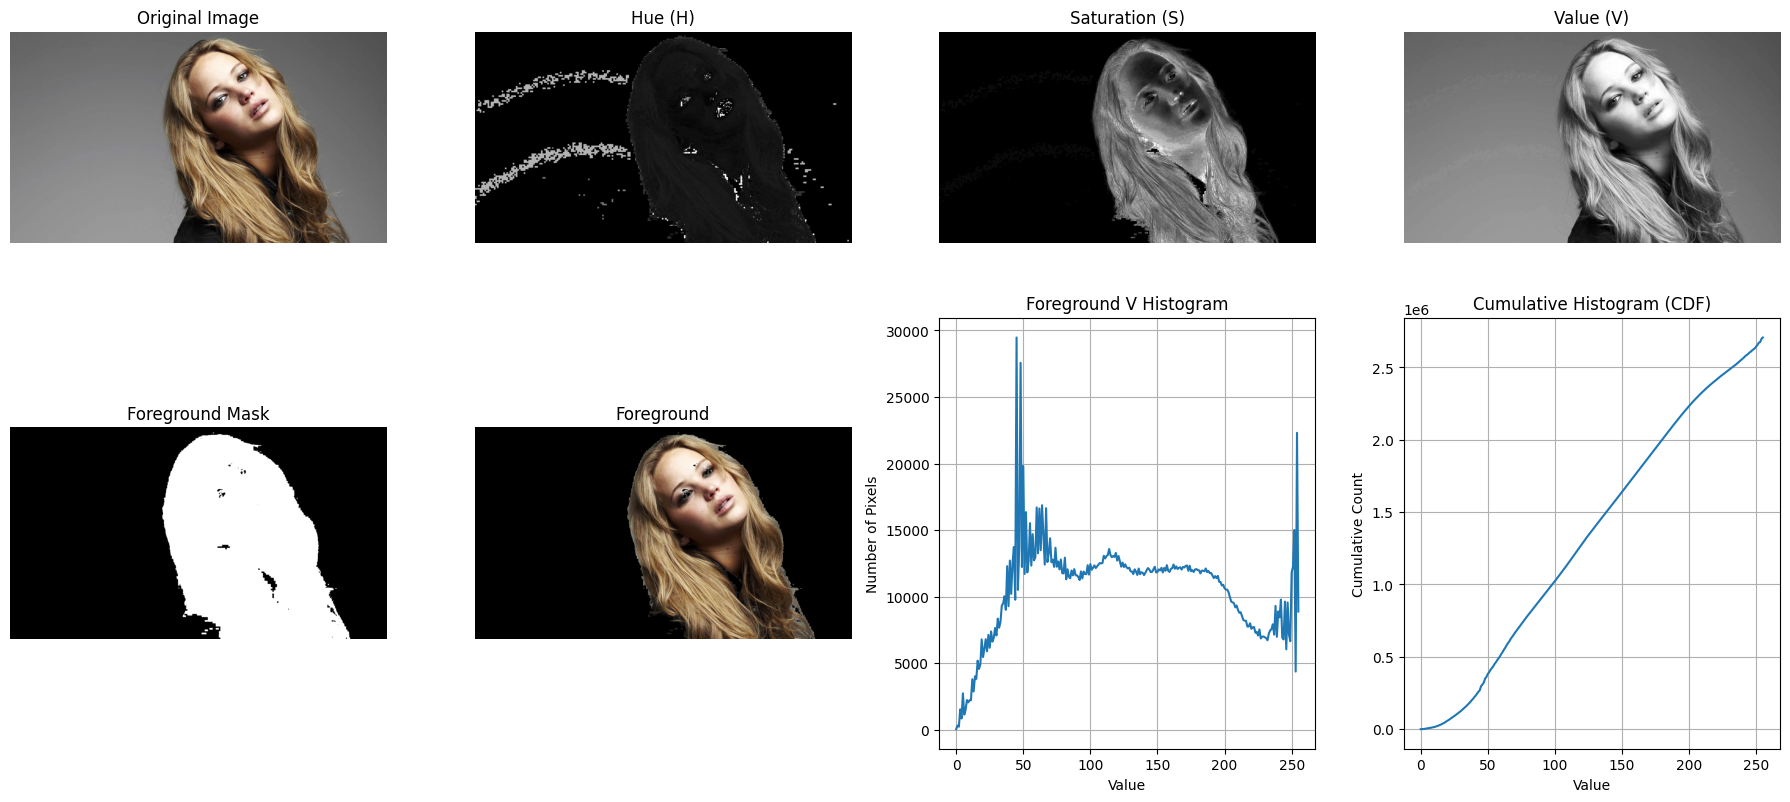

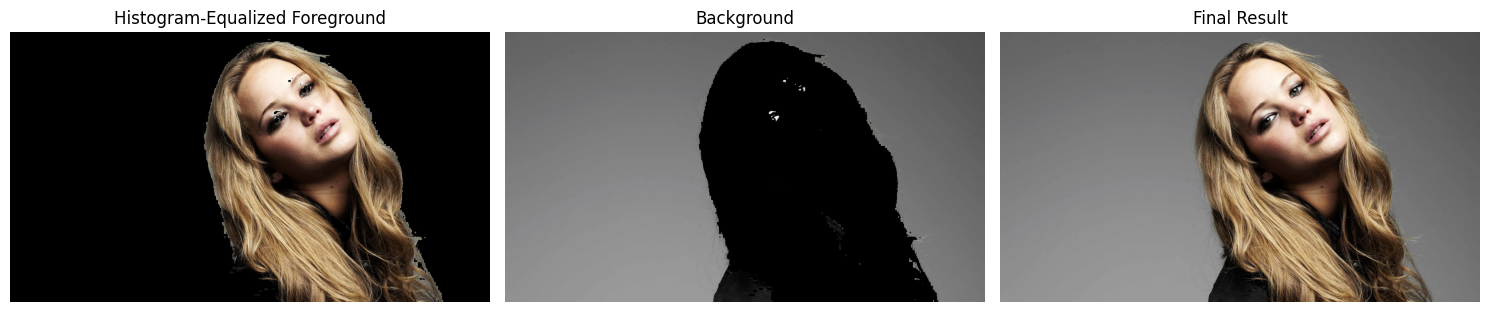

In [13]:
# (a) Open image, convert to HSV
image = cv.imread("images/jennifer.jpeg")
hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

# (b) Threshold the saturation plane to obtain foreground mask
_, mask = cv.threshold(s, 15, 255, cv.THRESH_BINARY)
# Remove small holes/noise in the mask
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
foreground_mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)

# (c) Extract foreground and compute its V-plane histogram
foreground = cv.bitwise_and(image, image, mask=foreground_mask)
# Convert foreground to HSV and obtain its Value plane
foreground_hsv = cv.cvtColor(foreground, cv.COLOR_BGR2HSV)
h1, s1, value_plane = cv.split(foreground_hsv)
# Histogram of V values only inside the foreground
hist = cv.calcHist([value_plane], [0], foreground_mask, [256], [0, 256]).flatten()

# (d) Obtain cumulative sum of the histogram
cdf = np.cumsum(hist)
MN = np.count_nonzero(foreground_mask) # Number of foreground pixels

# (e) Histogram-equalize the foreground
# s = (L-1)/MN * sum(n_j)
L = 256
# Create the transformation / lookup table
equalization_lut = np.round((L - 1) * cdf / MN).astype(np.uint8)
# Apply the transformation only to foreground pixels
value_equalized = value_plane.copy()
value_equalized[foreground_mask > 0] = equalization_lut[value_plane[foreground_mask > 0]]
# Reconstruct HSV image and convert back to BGR
equalized_hsv = cv.merge([h1, s1, value_equalized])
equalized_image = cv.cvtColor(equalized_hsv, cv.COLOR_HSV2BGR)

# (f) Extract background and combine it with equalized foreground
background_mask = cv.bitwise_not(foreground_mask)
background = cv.bitwise_and(image, image, mask=background_mask)
equalized_foreground = cv.bitwise_and(equalized_image, equalized_image, mask=foreground_mask)
result = cv.add(equalized_foreground, background)

fig, ax = plt.subplots(2, 4, figsize=(18, 9))
# Original image
ax[0, 0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB)); ax[0, 0].set_title("Original Image")
# H, S, V planes
ax[0, 1].imshow(h, cmap="gray"); ax[0, 1].set_title("Hue (H)")
ax[0, 2].imshow(s, cmap="gray"); ax[0, 2].set_title("Saturation (S)")
ax[0, 3].imshow(v, cmap="gray"); ax[0, 3].set_title("Value (V)")
# Foreground mask
ax[1, 0].imshow(foreground_mask, cmap="gray"); ax[1, 0].set_title("Foreground Mask")
# Foreground only
ax[1, 1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB)); ax[1, 1].set_title("Foreground")
# Histogram
ax[1, 2].plot(hist); ax[1, 2].set_title("Foreground V Histogram")
ax[1, 2].set_xlabel("Value"); ax[1, 2].set_ylabel("Number of Pixels")
ax[1, 2].grid(True)
# CDF
ax[1, 3].plot(cdf); ax[1, 3].set_title("Cumulative Histogram (CDF)")
ax[1, 3].set_xlabel("Value"); ax[1, 3].set_ylabel("Cumulative Count")
ax[1, 3].grid(True)

for a in ax.flat:
    a.axis("off")
# Keep axes for the histogram and CDF
ax[1, 2].axis("on"); ax[1, 3].axis("on")
plt.tight_layout(); plt.show()

# Second figure for final results
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv.cvtColor(equalized_foreground, cv.COLOR_BGR2RGB)); ax[0].set_title("Histogram-Equalized Foreground")
ax[1].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB)); ax[1].set_title("Background")
ax[2].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB)); ax[2].set_title("Final Result")

for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()
    